# Introduction

words

First let's import the modules we need and our data. 

In [1]:
import numpy as np
import duckdb
import polars as pl

import matplotlib.pyplot as plt

In [2]:
df = pl.read_parquet("/kaggle/input/datasets/ykevin000/sdss-public-service-dataset/big.parquet")

Following the analytical direction in the case, "Comparing average occupancy levels to peak occupancy events to assess system resilience", let's take a look at occupancy averages and maximums grouped by different columns. 


## Average and Maximums of Occupancy Rates  

In [3]:
#avg vs max rate grouped by sector 
duckdb.sql("""SELECT sector, AVG(occupancy_rate) AS avg_rate, MAX(occupancy_rate) AS max_rate, STDDEV_POP(occupancy_rate) AS standev
              FROM df 
              GROUP BY sector
              ORDER BY avg_rate""").show()

#avg vs max rate grouped by service type  
duckdb.sql("""SELECT overnight_service_type, AVG(occupancy_rate) AS avg_rate, MAX(occupancy_rate) AS max_rate
              FROM df 
              GROUP BY overnight_service_type
              ORDER BY avg_rate""").show()

#avg vs max rate grouped by program area 
duckdb.sql("""SELECT program_area, AVG(occupancy_rate) AS avg_rate, MAX(occupancy_rate) AS max_rate 
              FROM df 
              GROUP BY program_area
              ORDER BY avg_rate ASC""").show()

#avg vs max rate grouped by capacity type  
duckdb.sql("""SELECT capacity_type, AVG(occupancy_rate) AS avg_rate, MAX(occupancy_rate) AS max_rate
              FROM df 
              GROUP BY capacity_type
              ORDER BY avg_rate ASC""").show()

┌─────────────┬────────────────────┬──────────────────┬─────────────────────┐
│   SECTOR    │      avg_rate      │     max_rate     │       standev       │
│   varchar   │       double       │      double      │       double        │
├─────────────┼────────────────────┼──────────────────┼─────────────────────┤
│ Youth       │ 0.9430791013981389 │              1.0 │ 0.12115065293761898 │
│ Mixed Adult │ 0.9718532392262484 │              1.0 │  0.0995727627245522 │
│ Men         │ 0.9760693757431416 │ 1.01470588235294 │ 0.08021408448026744 │
│ Families    │ 0.9851799814896367 │              1.0 │  0.0602497979888603 │
│ Women       │ 0.9869279079753199 │ 1.01639344262295 │ 0.06624707981701583 │
└─────────────┴────────────────────┴──────────────────┴─────────────────────┘

┌────────────────────────────┬────────────────────┬──────────────────┐
│   OVERNIGHT_SERVICE_TYPE   │      avg_rate      │     max_rate     │
│          varchar           │       double       │      double      │
├─────

Looking at the maximum rate of occupancies, we know that exceeding a rate of 1 means more people are in a room than the set capacity of that room. Summarizing the data, we can see that the men and women sectors, shelter and 24-hour repsite site service types, base shelter and overnight system program areas, and bed-based capacity capacity types all exceed an occupancy rate of 1. 

Connecting these key pieces of data together, we can say that homelessness resources with "broader" descriptions tend to experience higher levels of overpopulation. For example, the 24 hour drop-in for women has a maximum rate of 1, whereas the 24 hour respite site is a similar resource—but allows for any gender—exceeds a rate of 1. 

I suggest looking into how resources for those shelters are allocated and focusing on places that accept a wider group of people as they tend to exceed maximum capacity. 

Now I want to specifically analyze the information from the first table. We can see the average rates for youth is significantly lower compared to other sectors. Also the difference between the max and average is around 6%, giving more leeway for youth sectors to counteract shocks. It is fair to say that the youth sector may be the most resillient based on this data. Thus, we should focus on other sectors that are in a more dire situation. 

Looking at the top three highest averages, we can see which sectors are struggling the most: women, families, and men, with averages of approximatly 98.7%, 98.5%, and 97.6%, respectively. Note that the standard deviations are relatively low (0.06, 0.06, and 0.08), so we can conclude that occupancy rates for these sectors do not deviate from the average by a darastic amount. Since the men and women sectors have a maximum exceeding 1, let's focus on those sectors, specifically how many times each sector surpasses the breaking point of occupancy rate = 1. 

# Counting Maximums and Rows

In [4]:
#Counting how many times a row hits max rate grouped by sector  
duckdb.sql("""SELECT sector, occupancy_rate, occupancy_date
              FROM df
              WHERE occupancy_rate > 1 """).show()

#Total rows with sector = men 
duckdb.sql("""SELECT COUNT(sector) AS men_count
FROM df
WHERE sector = 'Men'""").show()

#Total rows with sector = women 
duckdb.sql("""SELECT COUNT(sector) AS women_count
FROM df
WHERE sector = 'Women'""").show()

#Total rows with sector = families  
duckdb.sql("""SELECT COUNT(sector) AS families_count
FROM df
WHERE sector = 'Families'""").show()



┌─────────┬──────────────────┬─────────────────────┐
│ SECTOR  │  OCCUPANCY_RATE  │   OCCUPANCY_DATE    │
│ varchar │      double      │      timestamp      │
├─────────┼──────────────────┼─────────────────────┤
│ Men     │ 1.01470588235294 │ 2024-08-08 00:00:00 │
│ Men     │ 1.01470588235294 │ 2024-08-09 00:00:00 │
│ Men     │ 1.01470588235294 │ 2024-08-10 00:00:00 │
│ Men     │ 1.01470588235294 │ 2024-08-11 00:00:00 │
│ Men     │ 1.01470588235294 │ 2024-08-12 00:00:00 │
│ Men     │ 1.01408450704225 │ 2024-08-13 00:00:00 │
│ Women   │ 1.01612903225806 │ 2025-06-21 00:00:00 │
│ Women   │ 1.01639344262295 │ 2025-07-31 00:00:00 │
└─────────┴──────────────────┴─────────────────────┘

┌───────────┐
│ men_count │
│   int64   │
├───────────┤
│     25994 │
└───────────┘

┌─────────────┐
│ women_count │
│    int64    │
├─────────────┤
│       17784 │
└─────────────┘

┌────────────────┐
│ families_count │
│     int64      │
├────────────────┤
│          10393 │
└────────────────┘



We can see that men exceed an occupancy rate of 1 six times, all in the month of August 2024. For the women sector, a rate of 1 was exceeded only two times and both in 2025. Additionally, the number of rows with sectors for men is around 30% more than for women and around double the amount for family sectors. This indicates that the male homeless population has more shelters, but is exceeding the capacity more times than the women and family sectors. Although the women sector reaches a higher rate in magnitude, the frequency of shelters in the men's sector outweights that difference. For the family sector, it does not exceed a rate if 1 and seems to be floating above water for now.  

With that, I suggest finding ways to lower average occupancy rates for the men's and women's sector to decrease the frequency that the men sector over populates and give the women's sector more leeway when shocks occur, as the difference between the max and average rate for the women's sector is around 3.6% which is half of that of the youth sector. 

More specifically, I would suggest looking into why the men's sector exceeded the maximum more than any other sector and only in early to mid August of 2024. Some questions may be: Was there a policy change in August 2024 that effected the system's ability to handle a shock, leading to larger actual capacities? How can these shocks be counteracted?

With that, let's visualize the occupancy rates of the three sectors to really understand what is happening.



# Occupancy Rates Over Time  

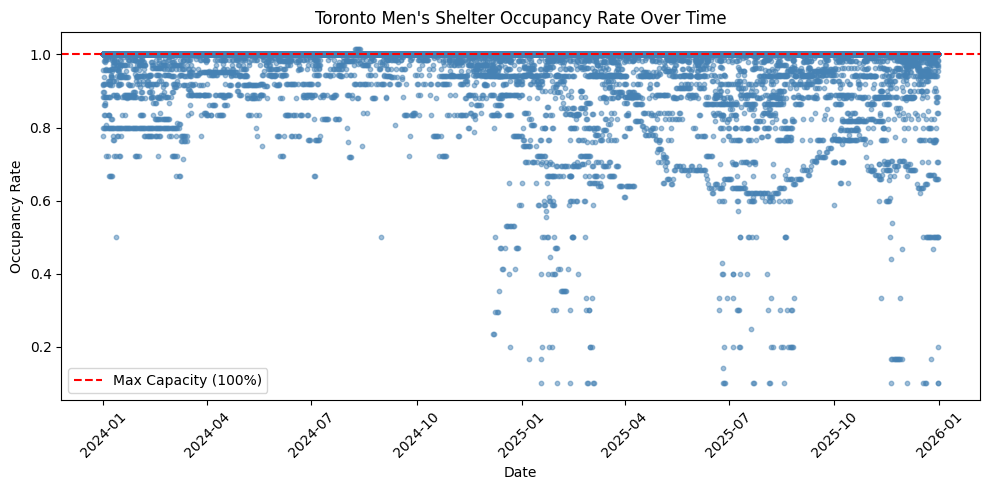

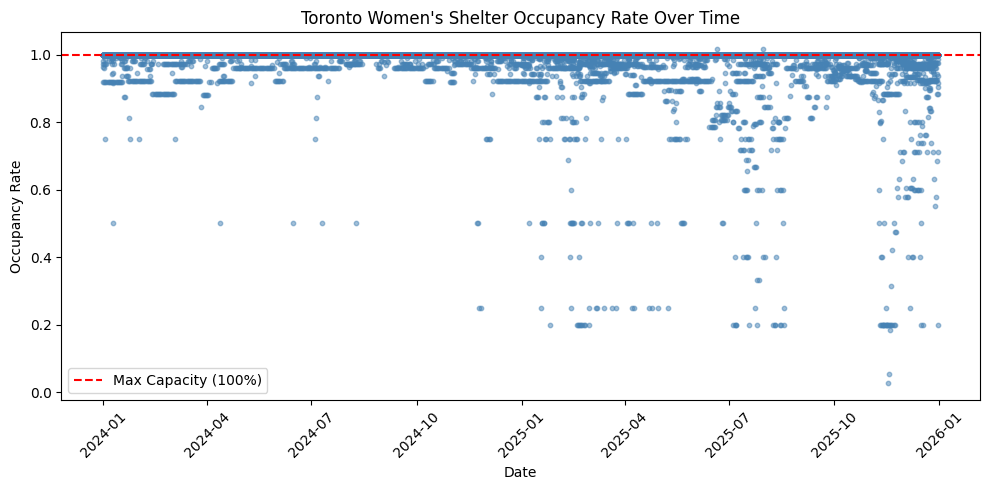

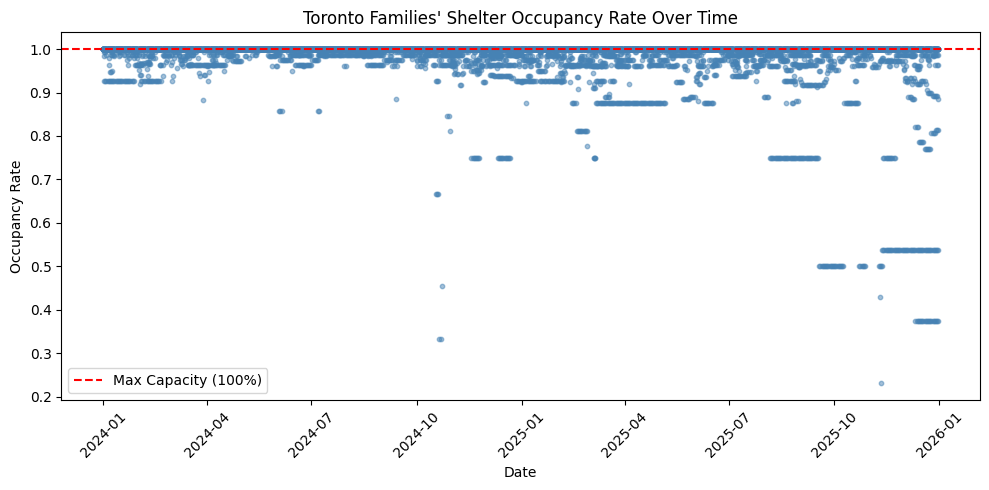

In [5]:
#filter the data to sector = men 
df_men = df.filter(pl.col('SECTOR') == 'Men')

#scatter plot for occupancy rates (of men) over time 
plt.figure(figsize=(10, 5))
plt.scatter(
    df_men['OCCUPANCY_DATE'].to_list(),
    df_men['OCCUPANCY_RATE'].to_list(),
    alpha=0.5,
    color='steelblue',
    s=10
)
plt.axhline(y=1.0, color='red', linestyle='--', label='Max Capacity (100%)')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.title('Toronto Men\'s Shelter Occupancy Rate Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#filter the data to sector = women 
df_women = df.filter(pl.col('SECTOR') == 'Women')

#scatter plot for occupancy rates (of women) over time 
plt.figure(figsize=(10, 5))
plt.scatter(
    df_women['OCCUPANCY_DATE'].to_list(),
    df_women['OCCUPANCY_RATE'].to_list(),
    alpha=0.5,
    color='steelblue',
    s=10
)
plt.axhline(y=1.0, color='red', linestyle='--', label='Max Capacity (100%)')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.title('Toronto Women\'s Shelter Occupancy Rate Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#filter the data to sector = families 
df_fam = df.filter(pl.col('SECTOR') == 'Families')

#scatter plot for occupancy rates (of women) over time 
plt.figure(figsize=(10, 5))
plt.scatter(
    df_fam['OCCUPANCY_DATE'].to_list(),
    df_fam['OCCUPANCY_RATE'].to_list(),
    alpha=0.5,
    color='steelblue',
    s=10
)
plt.axhline(y=1.0, color='red', linestyle='--', label='Max Capacity (100%)')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.title('Toronto Families\' Shelter Occupancy Rate Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As expected, the men and women sectors have higher occupancy rates, clustering towards a rate of 1. Some new insights include the unpredicatability of the men and women sectors shown by the variability of rates and the spread of all sectors changing in 2025. 

In 2025, all sector's rates seem to be spread throughout the graph, often well below the middle rate of 0.5. This indicates a shock has occured, bringing down occupation rates. I suggest looking into what the shock was and continuing to monitor the rates in 2026 to see the longivity and effectiveness of this shock. We will see clearly in the next section how occupancy rates of declined. 

Side note: Although rates reached lower magnitudes in 2025, my research shows that in 2018, around 8000 people in Toronto reported to be homeless, however in 2024 this number grew to over 15000. This growing trend paired with the housing crisis in Ontario may suggest that homelessness would increase in 2025, leading occupancy rates to increase. We see that is not the case here and it may be due to a bias or political skew in the data. 
Another article claims to be seeing a similar trend in an area of homeslessness: emcampment rates. The article says that encampments fell from 500 in 2024 to just under 200 in 2025. However advocates claim that the city is making homelessness 'less visible' by placing homeless people in emergency shelter, a short-term solution, to discourage them from living in public spaces. However, there is no concrete data on where these people go after leaving the emergency shelters. 


# The Decline of Occupancy Rates 

shape: (10, 3)
┌─────────────┬──────┬────────────────────┐
│ SECTOR      ┆ year ┆ avg_occupancy_rate │
│ ---         ┆ ---  ┆ ---                │
│ str         ┆ i32  ┆ f64                │
╞═════════════╪══════╪════════════════════╡
│ Families    ┆ 2024 ┆ 0.993982           │
│ Families    ┆ 2025 ┆ 0.976167           │
│ Men         ┆ 2024 ┆ 0.987638           │
│ Men         ┆ 2025 ┆ 0.964686           │
│ Mixed Adult ┆ 2024 ┆ 0.9876             │
│ Mixed Adult ┆ 2025 ┆ 0.957132           │
│ Women       ┆ 2024 ┆ 0.995919           │
│ Women       ┆ 2025 ┆ 0.97831            │
│ Youth       ┆ 2024 ┆ 0.952988           │
│ Youth       ┆ 2025 ┆ 0.934567           │
└─────────────┴──────┴────────────────────┘
shape: (10, 4)
┌─────────────┬──────┬────────────────────┬─────────────┐
│ SECTOR      ┆ year ┆ avg_occupancy_rate ┆ rate_change │
│ ---         ┆ ---  ┆ ---                ┆ ---         │
│ str         ┆ i32  ┆ f64                ┆ f64         │
╞═════════════╪══════╪════════════

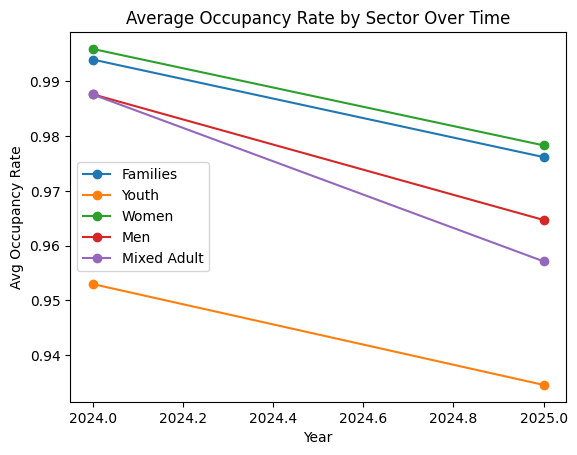

In [6]:
#Calculating average annual occupancy rate grouped by sectors 
df_yearly = df.with_columns(
    pl.col('OCCUPANCY_DATE').dt.year().alias('year')
).group_by(['SECTOR', 'year']).agg(
    pl.col('OCCUPANCY_RATE').mean().alias('avg_occupancy_rate')
).sort(['SECTOR', 'year'])

print(df_yearly)

#Calculating the change/growth rates of average occupancy per year grouped by sectors
df_change = df_yearly.with_columns(
    pl.col('avg_occupancy_rate').diff().over('SECTOR').alias('rate_change')
)

print(df_change)

#Graphing the average occupancy rates over time 
for sector in df_change['SECTOR'].unique().to_list():
    subset = df_change.filter(pl.col('SECTOR') == sector)
    plt.plot(subset['year'].to_list(), subset['avg_occupancy_rate'].to_list(), label=sector, marker='o')

plt.legend()
plt.title('Average Occupancy Rate by Sector Over Time')
plt.xlabel('Year')
plt.ylabel('Avg Occupancy Rate')
plt.show()

It is more clear how the occupancy rates have decreased from 2024 to 2025 from some sort of shock, reguardless of the housing crisis and increased prices within the economy. 

# Final Remarks 

Here is a summary of the conclusions that came from comparing average and maximum occupancy rates: 

- Shelters that allow for a broader population to enter tend to be less resillient by looking at  occupation rates that exceed 1 
- The difference between the maximum and average is one way to measure resillience
- This difference shows that the youth sector may handle shock better than other sectors
- After comparing ocupational rates over time, the men's sector may need the most attention and is the least resillient sector  
- There was a shock that positvely effected ocupational rates in 2025, leading them to decrease; finding why rates decreased in 2025 may be vital to creating a more resillient structure 

shape: (10, 3)
┌─────────────┬──────┬─────────────────────┐
│ SECTOR      ┆ year ┆ avg_actual_capacity │
│ ---         ┆ ---  ┆ ---                 │
│ str         ┆ i32  ┆ f64                 │
╞═════════════╪══════╪═════════════════════╡
│ Families    ┆ 2024 ┆ 56.008368           │
│ Families    ┆ 2025 ┆ 53.994742           │
│ Men         ┆ 2024 ┆ 61.82524            │
│ Men         ┆ 2025 ┆ 58.335979           │
│ Mixed Adult ┆ 2024 ┆ 71.628002           │
│ Mixed Adult ┆ 2025 ┆ 61.918112           │
│ Women       ┆ 2024 ┆ 44.735983           │
│ Women       ┆ 2025 ┆ 41.623899           │
│ Youth       ┆ 2024 ┆ 30.309061           │
│ Youth       ┆ 2025 ┆ 29.110244           │
└─────────────┴──────┴─────────────────────┘
shape: (10, 5)
┌─────────────┬──────┬─────────────────────┬────────────────────┬─────────────┐
│ SECTOR      ┆ year ┆ avg_actual_capacity ┆ prev_year_capacity ┆ growth_rate │
│ ---         ┆ ---  ┆ ---                 ┆ ---                ┆ ---         │
│ str     

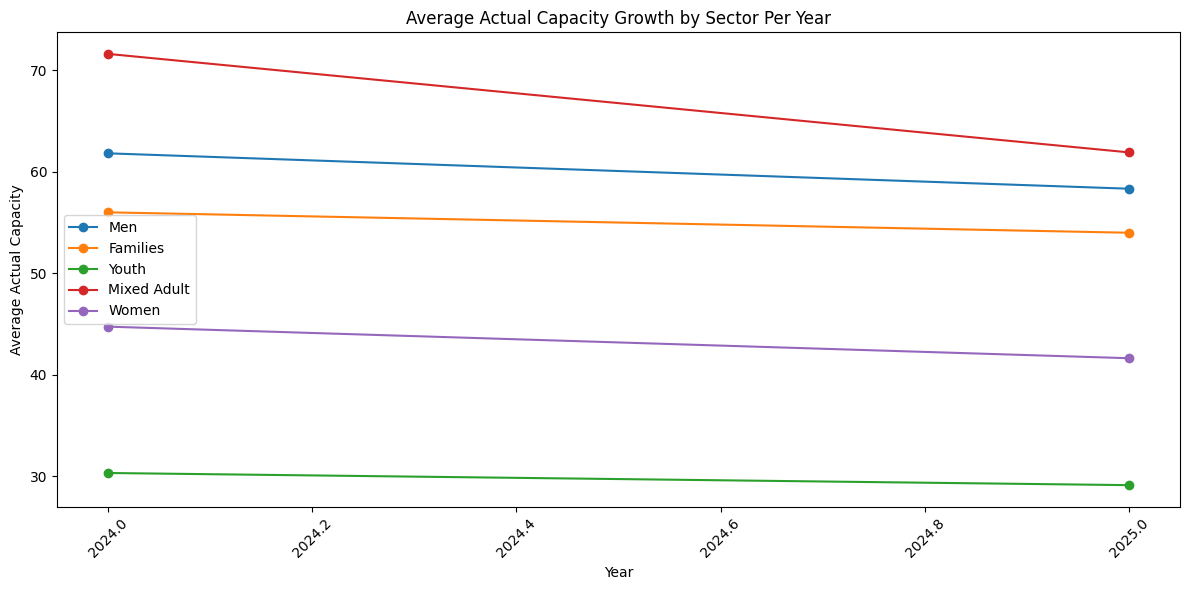

In [7]:
#calculating average actual capacity grouped by sector 
df_capacity = df.with_columns(
    pl.col('OCCUPANCY_DATE').dt.year().alias('year')
).group_by(['SECTOR', 'year']).agg(
    pl.col('ACTUAL_CAPACITY').mean().alias('avg_actual_capacity')
).sort(['SECTOR', 'year'])

print(df_capacity) 


df_growth = df_capacity.with_columns(
    pl.col('avg_actual_capacity').shift(1).over('SECTOR').alias('prev_year_capacity')
).with_columns(
    ((pl.col('avg_actual_capacity') - pl.col('prev_year_capacity')) / pl.col('prev_year_capacity') * 100).alias('growth_rate')
)

print(df_growth)

plt.figure(figsize=(12, 6))

for sector in df_capacity['SECTOR'].unique().to_list():
    subset = df_capacity.filter(pl.col('SECTOR') == sector)
    plt.plot(
        subset['year'].to_list(),
        subset['avg_actual_capacity'].to_list(),
        label=sector,
        marker='o'
    )

plt.xlabel('Year')
plt.ylabel('Average Actual Capacity')
plt.title('Average Actual Capacity Growth by Sector Per Year')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()